In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

c:\Users\Hemanth Sai\OneDrive\Desktop\info\queytube\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load cleaned dataset
df = pd.read_csv("cleaned_transcripts.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check required columns
required_cols = ["video_id", "title", "datetime", "transcript"]
for col in required_cols:
    if col not in df.columns:
        print(f"Missing column: {col}")

Dataset loaded successfully
Shape: (345, 4)
Columns: ['video_id', 'title', 'datetime', 'transcript']


In [3]:
# Best model from Module 5
model_name = "all-mpnet-base-v2"

print(f"Loading model: {model_name}")
model = SentenceTransformer(model_name)

print("Model loaded successfully")

Loading model: all-mpnet-base-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2630.06it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [4]:
# Fill missing values (safety)
df["title"] = df["title"].fillna("")
df["transcript"] = df["transcript"].fillna("")

titles = df["title"].tolist()
transcripts = df["transcript"].tolist()

print("Total titles:", len(titles))
print("Total transcripts:", len(transcripts))

Total titles: 345
Total transcripts: 345


In [5]:
print("Generating title embeddings...")

title_embeddings = model.encode(
    titles,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Title embeddings shape:", title_embeddings.shape)

Generating title embeddings...


Batches: 100%|██████████| 11/11 [00:07<00:00,  1.46it/s]

Title embeddings shape: (345, 768)


In [7]:
print("Generating transcript embeddings...")

transcript_embeddings = model.encode(
    transcripts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Transcript embeddings shape:", transcript_embeddings.shape)

Generating transcript embeddings...


Batches: 100%|██████████| 11/11 [02:45<00:00, 15.02s/it]

Transcript embeddings shape: (345, 768)


In [8]:
print("Combining embeddings...")

combined_embeddings = (title_embeddings + transcript_embeddings) / 2

print("Combined embeddings shape:", combined_embeddings.shape)

Combining embeddings...
Combined embeddings shape: (345, 768)


In [9]:
print("Appending embeddings to dataset...")

# Convert embeddings to DataFrame
embedding_df = pd.DataFrame(combined_embeddings)

# Rename columns (embedding_1, embedding_2, ...)
embedding_df.columns = [f"embedding_{i}" for i in range(embedding_df.shape[1])]

# Concatenate with original dataset
final_df = pd.concat([df, embedding_df], axis=1)

print("Final dataset shape:", final_df.shape)

Appending embeddings to dataset...
Final dataset shape: (345, 772)


In [15]:
embedding_df.head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,0.018227,0.048077,-0.043131,-0.027831,-0.003672,-0.063867,0.004778,0.016750,0.038513,0.026279,...,-0.024708,-0.040338,-0.038380,-0.014533,-0.017045,0.006067,-0.012975,-0.010151,0.067087,-0.003882
1,-0.040895,0.020834,-0.051575,0.014889,0.005652,0.006120,0.048744,0.000480,-0.000700,-0.010076,...,-0.005669,0.016138,0.059081,0.003138,-0.043135,0.010756,-0.032106,-0.060180,-0.006822,-0.017025
2,0.007612,0.026643,-0.044237,-0.034639,-0.015858,0.015978,0.017508,0.013101,-0.039645,0.029540,...,-0.047760,0.038290,-0.012460,-0.021454,-0.029015,0.044420,-0.019512,-0.012131,0.059034,-0.028631
3,0.045482,0.005659,-0.009941,-0.022660,0.013231,0.012872,-0.061654,-0.009123,-0.033262,0.071246,...,0.025263,0.029258,-0.035736,-0.029711,-0.008038,-0.029292,0.019293,-0.009302,0.079837,-0.035481
4,0.019499,-0.015900,0.012543,-0.017748,0.020654,-0.033333,0.091951,0.053824,-0.057294,-0.060119,...,-0.004075,-0.004162,-0.028495,0.026951,0.019217,0.038177,-0.000040,-0.003350,0.022095,-0.018804


In [16]:
final_df.head()

,video_id,title,datetime,transcript,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,cw02dMpWStI,How to find good open source projects to contr...,2026-03-04 13:29:25+00:00,when I was in I was working I was probably wor...,0.018227,0.048077,-0.043131,-0.027831,-0.003672,-0.063867,...,-0.024708,-0.040338,-0.038380,-0.014533,-0.017045,0.006067,-0.012975,-0.010151,0.067087,-0.003882
1,0WjfKQdfeMU,NVIDIACertified Associate AI Infrastructure an...,2026-03-04 11:00:02+00:00,Hey this is Andrew Brown bringing you another ...,-0.040895,0.020834,-0.051575,0.014889,0.005652,0.006120,...,-0.005669,0.016138,0.059081,0.003138,-0.043135,0.010756,-0.032106,-0.060180,-0.006822,-0.017025
2,ZldNCx4AvEM,Learn the basics of Git in 60 seconds with Bea...,2026-03-03 13:05:25+00:00,Lets learn the basics of Git in less than 60 s...,0.007612,0.026643,-0.044237,-0.034639,-0.015858,0.015978,...,-0.047760,0.038290,-0.012460,-0.021454,-0.029015,0.044420,-0.019512,-0.012131,0.059034,-0.028631
3,E7o_WdfKszU,Theres so much to learn so how do you focus to...,2026-03-02 13:17:28+00:00,And you know what one thing I will say is I th...,0.045482,0.005659,-0.009941,-0.022660,0.013231,0.012872,...,0.025263,0.029258,-0.035736,-0.029711,-0.008038,-0.029292,0.019293,-0.009302,0.079837,-0.035481
4,IBTx5aGj-6U,Build Your Own Video Sharing App Loom Clone wi...,2026-03-02 11:00:33+00:00,In this course were going to build a fully fun...,0.019499,-0.015900,0.012543,-0.017748,0.020654,-0.033333,...,-0.004075,-0.004162,-0.028495,0.026951,0.019217,0.038177,-0.000040,-0.003350,0.022095,-0.018804


In [10]:
output_file = "video_index.csv"

final_df.to_csv(output_file, index=False)

print(f"Video index saved as: {output_file}")

Video index saved as: video_index.csv


In [11]:
print("Verifying data integrity...\n")

# Check rows
print("Total rows:", final_df.shape[0])

# Check embedding columns
embedding_cols = [col for col in final_df.columns if "embedding_" in col]

print("Number of embedding dimensions:", len(embedding_cols))

# Check null values
null_count = final_df[embedding_cols].isnull().sum().sum()
print("Total null values in embeddings:", null_count)

# Check consistency
print("Sample embedding vector length:", len(final_df.iloc[0][embedding_cols]))

print("\nVerification completed")

Verifying data integrity...

Total rows: 345
Number of embedding dimensions: 768
Total null values in embeddings: 0
Sample embedding vector length: 768

Verification completed


Reducing dimensions using PCA...


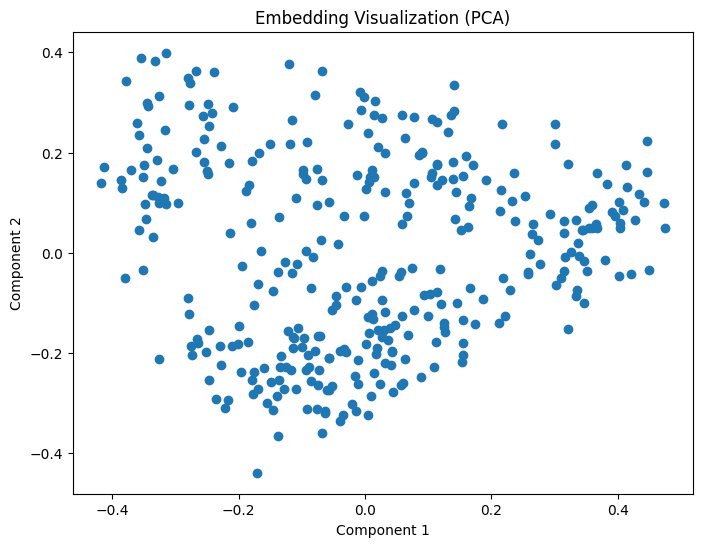

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Reducing dimensions using PCA...")

pca = PCA(n_components=2)
reduced = pca.fit_transform(combined_embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("Embedding Visualization (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [17]:
# ================================
# Final Cell: Search using Euclidean Distance
# ================================

import numpy as np
from scipy.spatial.distance import cdist

# Example query (you can change this)
query = "What is the difference between unit testing and integration testing?"

print(f"\nQuery: {query}\n")

# Step 1: Convert query to embedding
query_embedding = model.encode([query], convert_to_numpy=True)

# Step 2: Compute Euclidean distance (convert to similarity using negative)
scores = -cdist(query_embedding, combined_embeddings, metric="euclidean")

# Step 3: Rank videos (highest score = best match)
ranked_idx = np.argsort(scores[0])[::-1]

# Step 4: Show Top-K results
top_k = 5

print("Top Results:\n")

for i in range(top_k):
    idx = ranked_idx[i]
    
    print(f"Rank {i+1}")
    print(f"Video ID : {df.iloc[idx]['video_id']}")
    print(f"Title    : {df.iloc[idx]['title']}")
    print(f"Score    : {scores[0][idx]:.4f}")
    print("-" * 50)


Query: What is the difference between unit testing and integration testing?

Top Results:

Rank 1
Video ID : Yygu7TBWdPs
Title    : Easily Create E2E Tests with KaneAI
Score    : -1.1287
--------------------------------------------------
Rank 2
Video ID : s950xhRvqYQ
Title    : The ultimate dev skill is Integration Testing feat Internet of Bugs Podcast 209
Score    : -1.1729
--------------------------------------------------
Rank 3
Video ID : ry_mcAPVTOc
Title    : Whats the difference between call vs apply in JavaScript
Score    : -1.1845
--------------------------------------------------
Rank 4
Video ID : UIf-SlmMays
Title    : n8n Tutorial Zero to Hero Course
Score    : -1.2088
--------------------------------------------------
Rank 5
Video ID : ikXDYsdg15c
Title    : Function declaration vs expression whats the difference
Score    : -1.2194
--------------------------------------------------
